# Weather API Comparison EDA

Look at a few open source weather APIs and do a bit of EDA with them to see if one is best for this project. Looking at HRRR, RTMA, NWS, and Open-Meteo to figure out which provides the best combination of spatial resolution, historical coverage, variable availability, and ingestion complexity for use as training and inference features. 

One of the issues around this is that the NASA VIIRS satellite data has a spatial resolution of 375m, however, many of the public facing weather APIs have a finest resolution of around 2.5km - 3km, so need to determine if this disparity in resolution is acceptable for the weather (there are finer resolutions available from paid APIs).

Anchoring around a single large wild fire event in the past: DOE fire (Aug 17 - Sep 4, 2020).

findings at the end

In [1]:
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
from herbie import Herbie
import math
from pyproj import Transformer
import pyarrow.parquet as pq

In [2]:
# DOE fire anchor (ICS-209 point of origin)
DOE_CENTROID_LAT = 39.7654
DOE_CENTROID_LON = -122.6733

# Bounding box around DOE fire (plus a 1 degree buffer in each direction)
DOE_BBOX = (-123.6733, 38.7654, -121.6733, 40.7654)

DOE_PEAK_DATE = "2020-08-19"
DOE_PEAK_HOUR = 21  # in UTC

DOE_START = "2020-08-16"
DOE_END = "2020-09-04"

In [3]:
# starting place for fire-relevant features to look for across the APIs
TARGET_VARIABLES = [
    "wind_speed",
    "wind_direction",
    "relative_humidity",
    "temperature_2m",
    "dew_point",
    "precipitation",
]

## HRRR (3km) via herbie

HRRR (High-Resolution Rapid Refresh): 3km, CONUS, hourly, updated hourly, available ~2014–present on AWS S3.
Access via the `herbie` Python library.

In [4]:
hrrr_valid_time = pd.Timestamp(DOE_PEAK_DATE) + pd.Timedelta(hours=DOE_PEAK_HOUR)

hrrr = Herbie(
    hrrr_valid_time,
    model="hrrr",
    product="sfc",
    fxx=0,
    priority=["aws", "google"],
)

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


In [5]:
hrrr_inventory = hrrr.inventory()
display(hrrr_inventory.head())
display(
    hrrr_inventory[
        hrrr_inventory["search_this"].str.contains(
            r":(?:TMP|DPT|RH|UGRD|VGRD|APCP):", regex=True, na=False
        )
    ][["search_this"]].drop_duplicates()
)

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,456236.0,0-456236,2020-08-19 21:00:00,2020-08-19 21:00:00,REFC,entire atmosphere,anl,:REFC:entire atmosphere:anl:
1,2,456237,775085.0,456237-775085,2020-08-19 21:00:00,2020-08-19 21:00:00,RETOP,cloud top,anl,:RETOP:cloud top:anl:
2,3,775086,1084209.0,775086-1084209,2020-08-19 21:00:00,2020-08-19 21:00:00,VIL,entire atmosphere,anl,:VIL:entire atmosphere:anl:
3,4,1084210,2371881.0,1084210-2371881,2020-08-19 21:00:00,2020-08-19 21:00:00,VIS,surface,anl,:VIS:surface:anl:
4,5,2371882,2613949.0,2371882-2613949,2020-08-19 21:00:00,2020-08-19 21:00:00,REFD,1000 m above ground,anl,:REFD:1000 m above ground:anl:


,search_this
8,:UGRD:250 mb:anl:
9,:VGRD:250 mb:anl:
10,:UGRD:300 mb:anl:
11,:VGRD:300 mb:anl:
13,:TMP:500 mb:anl:
14,:DPT:500 mb:anl:
15,:UGRD:500 mb:anl:
16,:VGRD:500 mb:anl:
18,:TMP:700 mb:anl:
19,:DPT:700 mb:anl:


In [6]:
# HRRR GRIB2 search strings for fire-relevant variables
HRRR_SEARCH = {
    "temperature_2m": r":TMP:2 m",
    "dew_point": r":DPT:2 m",
    "relative_humidity": r":RH:2 m",
    "u_wind_10m": r":UGRD:10 m",
    "v_wind_10m": r":VGRD:10 m",
}

# For precipitation at the target hour, we need to look at the
# one-hour accumulation ending at that time
HRRR_PRECIP_SEARCH = r":APCP:surface:0-1 hour"

In [7]:
def _point_df(lat, lon):
    return pd.DataFrame({"latitude": [lat], "longitude": [lon]})


def _first_data_var(ds):
    return next(v for v in ds.data_vars if v != "gribfile_projection")


def _pick_scalar(ds, lat, lon):
    picked = ds.herbie.pick_points(_point_df(lat, lon), method="nearest")
    var = _first_data_var(picked)
    return float(picked[var].isel(point=0).item()), picked


def _rh_from_temp_dewpoint_k(temp_k, dewpoint_k):
    """Approximate RH (%) from temperature/dew point in Kelvin."""
    temp_c = temp_k - 273.15
    dewpoint_c = dewpoint_k - 273.15
    rh = 100 * np.exp(
        (17.625 * dewpoint_c) / (243.04 + dewpoint_c)
        - (17.625 * temp_c) / (243.04 + temp_c)
    )
    return float(np.clip(rh, 0, 100))


def fetch_hrrr_point(lat, lon, date, hour=None):
    """
    Fetch fire-relevant HRRR variables at a single lat/lon for a date/hour.

    date: YYYY-MM-DD
    hour: UTC hour integer, 0-23

    Returns a flat dict keyed by TARGET_VARIABLES-style names.
    """
    if hour is not None:
        valid_time = pd.Timestamp(date) + pd.Timedelta(hours=hour)
    else:
        valid_time = pd.Timestamp(date)
    h = Herbie(
        valid_time, model="hrrr", product="sfc", fxx=0, priority=["aws", "google"]
    )

    out = {
        "source": "HRRR",
        "valid_time_utc": valid_time,
        "latitude_requested": lat,
        "longitude_requested": lon,
    }

    grid_metadata_captured = False

    for name, search in HRRR_SEARCH.items():
        try:
            ds = h.xarray(search)
            value, picked = _pick_scalar(ds, lat, lon)
            out[name] = value

            if not grid_metadata_captured:
                if "point_grid_distance" in picked:
                    out["grid_distance_km"] = float(
                        picked["point_grid_distance"].isel(point=0).item()
                    )
                if "latitude" in picked:
                    out["grid_latitude"] = float(
                        picked["latitude"].isel(point=0).item()
                    )
                if "longitude" in picked:
                    grid_lon = float(picked["longitude"].isel(point=0).item())
                    out["grid_longitude"] = (
                        grid_lon - 360 if grid_lon > 180 else grid_lon
                    )
                grid_metadata_captured = True

        except Exception as exc:
            out[name] = np.nan
            out[f"{name}_error"] = repr(exc)

    # Wind speed and meteorological direction from u/v components
    if np.isfinite(out.get("u_wind_10m", np.nan)) and np.isfinite(
        out.get("v_wind_10m", np.nan)
    ):
        u = out["u_wind_10m"]
        v = out["v_wind_10m"]
        out["wind_speed"] = float(np.hypot(u, v))
        out["wind_direction"] = float((270 - np.degrees(np.arctan2(v, u))) % 360)

    # If RH field is absent, derive it from 2m temp/dewpoint
    if not np.isfinite(out.get("relative_humidity", np.nan)):
        if np.isfinite(out.get("temperature_2m", np.nan)) and np.isfinite(
            out.get("dew_point", np.nan)
        ):
            out["relative_humidity"] = _rh_from_temp_dewpoint_k(
                out["temperature_2m"], out["dew_point"]
            )

    # One-hour accumulated precipitation ending at valid_time
    try:
        precip_init = valid_time - pd.Timedelta(hours=1)
        hp = Herbie(
            precip_init, model="hrrr", product="sfc", fxx=1, priority=["aws", "google"]
        )
        ds_p = hp.xarray(HRRR_PRECIP_SEARCH)
        out["precipitation"], _ = _pick_scalar(ds_p, lat, lon)
    except Exception as exc:
        out["precipitation"] = np.nan
        out["precipitation_error"] = repr(exc)

    return out

In [8]:
hrrr_centroid = fetch_hrrr_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    DOE_PEAK_DATE,
    DOE_PEAK_HOUR,
)

hrrr_historical_check = fetch_hrrr_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    "2018-01-01",
    21,
)

display(hrrr_centroid)
display(hrrr_historical_check)

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 20:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2018-Jan-01 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2018-Jan-01 20:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local


{'source': 'HRRR',
 'valid_time_utc': Timestamp('2020-08-19 21:00:00'),
 'latitude_requested': 39.7654,
 'longitude_requested': -122.6733,
 'temperature_2m': 302.286865234375,
 'grid_distance_km': 1.7674468280546733,
 'grid_latitude': 39.78055188034116,
 'grid_longitude': -122.66705035146293,
 'dew_point': 267.9554138183594,
 'relative_humidity': 11.0,
 'u_wind_10m': 3.8256778717041016,
 'v_wind_10m': -1.0995426177978516,
 'wind_speed': 3.9805533718818764,
 'wind_direction': 286.0352430737424,
 'precipitation': 0.0}

{'source': 'HRRR',
 'valid_time_utc': Timestamp('2018-01-01 21:00:00'),
 'latitude_requested': 39.7654,
 'longitude_requested': -122.6733,
 'temperature_2m': 286.0864562988281,
 'grid_distance_km': 1.7674468280546733,
 'grid_latitude': 39.78055188034116,
 'grid_longitude': -122.66705035146293,
 'dew_point': 272.3951721191406,
 'relative_humidity': 40.599998474121094,
 'u_wind_10m': -2.7804718017578125,
 'v_wind_10m': -1.179046630859375,
 'wind_speed': 3.020128208886368,
 'wind_direction': 67.02084450931306,
 'precipitation': 0.0}

In [9]:
hrrr_historical_check = fetch_hrrr_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    "2014-08-01",
)

# actual historical coverage start for HRRR is around 2014-08-01,
# but the key point is whether it covers the full training window starting 2018-01-01

💔 Did not find ┊ model=hrrr ┊ product=sfc ┊ 2014-Aug-01 00:00 UTC F00
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2014-Jul-31 23:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local


/Users/pabloaganza/Documents/Workstation/projects/wildfire/.venv/lib/python3.14/site-packages/herbie/core.py:1280: UserWarning: Will not remove GRIB file because it previously existed.
  warnings.warn("Will not remove GRIB file because it previously existed.")


In [10]:
hrrr_summary = {
    "spatial_resolution_km": 3,
    "temporal_resolution_h": 1,
    "historical_coverage_start": "2014-08-01",
    "ingestion_complexity": "herbie + GRIB2/cfgrib + point extraction",
    "variables_available": [
        k for k in TARGET_VARIABLES if k in hrrr_centroid and pd.notna(hrrr_centroid[k])
    ],
    "variables_missing": [
        k
        for k in TARGET_VARIABLES
        if k not in hrrr_centroid or pd.isna(hrrr_centroid[k])
    ],
    "historical_coverage_verified_to": (
        hrrr_historical_check["valid_time_utc"].date().isoformat()
        if "valid_time_utc" in hrrr_historical_check
        else f"FAILED: {hrrr_historical_check.get('error', 'unknown')}"
    ),
    "grid_distance_km": hrrr_centroid.get("grid_distance_km"),
    "suitable_for_training": True,
    "suitable_for_inference": True,
}

hrrr_summary

{'spatial_resolution_km': 3,
 'temporal_resolution_h': 1,
 'historical_coverage_start': '2014-08-01',
 'ingestion_complexity': 'herbie + GRIB2/cfgrib + point extraction',
 'variables_available': ['wind_speed',
  'wind_direction',
  'relative_humidity',
  'temperature_2m',
  'dew_point',
  'precipitation'],
 'variables_missing': [],
 'historical_coverage_verified_to': '2014-08-01',
 'grid_distance_km': 1.7674468280546733,
 'suitable_for_training': True,
 'suitable_for_inference': True}

some notes:
- Use fxx=0 for instantaneous fields at the valid hour
- Use previous cycle fxx=1 for 1-hour APCP ending at the valid hour
- Wind speed/direction are derived from 10m UGRD/VGRD

## RTMA (2.5km) via herbie

RTMA (Real-Time Mesoscale Analysis): 2.5km, CONUS, hourly analysis product (not forecast).
Analysis products give best estimate of what weather *was* at a given time - well-suited for training data.
Access via herbie, model name: 'rtma'.

In [11]:
# RTMA is an analysis product so no forecast hour -> fxx is always 0
rtma = Herbie(
    hrrr_valid_time,
    model="rtma",
    product="anl",
    fxx=0,
    priority=["aws", "google"],
)

✅ Found ┊ model=rtma ┊ product=anl ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


In [12]:
rtma_inventory = rtma.inventory()
display(rtma_inventory.head())

display(
    rtma_inventory[
        rtma_inventory["search_this"].str.contains(
            r":(?:TMP|DPT|RH|UGRD|VGRD|WIND|WDIR|GUST|APCP):", regex=True, na=False
        )
    ][["search_this"]].drop_duplicates()
)

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,7490117.0,0-7490117,2020-08-19 21:00:00,2020-08-19 21:00:00,HGT,surface,anl,:HGT:surface:anl:
1,2,7490118,14980235.0,7490118-14980235,2020-08-19 21:00:00,2020-08-19 21:00:00,PRES,surface,anl,:PRES:surface:anl:
2,3,14980236,21065992.0,14980236-21065992,2020-08-19 21:00:00,2020-08-19 21:00:00,TMP,2 m above ground,anl,:TMP:2 m above ground:anl:
3,4,21065993,27151749.0,21065993-27151749,2020-08-19 21:00:00,2020-08-19 21:00:00,DPT,2 m above ground,anl,:DPT:2 m above ground:anl:
4,5,27151750,33237506.0,27151750-33237506,2020-08-19 21:00:00,2020-08-19 21:00:00,UGRD,10 m above ground,anl,:UGRD:10 m above ground:anl:


,search_this
2,:TMP:2 m above ground:anl:
3,:DPT:2 m above ground:anl:
4,:UGRD:10 m above ground:anl:
5,:VGRD:10 m above ground:anl:
7,:WDIR:10 m above ground:anl:
8,:WIND:10 m above ground:anl:
9,:GUST:10 m above ground:anl:


In [13]:
display(rtma_inventory.drop_duplicates())

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,7490117.0,0-7490117,2020-08-19 21:00:00,2020-08-19 21:00:00,HGT,surface,anl,:HGT:surface:anl:
1,2,7490118,14980235.0,7490118-14980235,2020-08-19 21:00:00,2020-08-19 21:00:00,PRES,surface,anl,:PRES:surface:anl:
2,3,14980236,21065992.0,14980236-21065992,2020-08-19 21:00:00,2020-08-19 21:00:00,TMP,2 m above ground,anl,:TMP:2 m above ground:anl:
3,4,21065993,27151749.0,21065993-27151749,2020-08-19 21:00:00,2020-08-19 21:00:00,DPT,2 m above ground,anl,:DPT:2 m above ground:anl:
4,5,27151750,33237506.0,27151750-33237506,2020-08-19 21:00:00,2020-08-19 21:00:00,UGRD,10 m above ground,anl,:UGRD:10 m above ground:anl:
5,6,33237507,39323263.0,33237507-39323263,2020-08-19 21:00:00,2020-08-19 21:00:00,VGRD,10 m above ground,anl,:VGRD:10 m above ground:anl:
6,7,39323264,46345261.0,39323264-46345261,2020-08-19 21:00:00,2020-08-19 21:00:00,SPFH,2 m above ground,anl,:SPFH:2 m above ground:anl:
7,8,46345262,51962897.0,46345262-51962897,2020-08-19 21:00:00,2020-08-19 21:00:00,WDIR,10 m above ground,anl,:WDIR:10 m above ground:anl:
8,9,51962898,57580533.0,51962898-57580533,2020-08-19 21:00:00,2020-08-19 21:00:00,WIND,10 m above ground,anl,:WIND:10 m above ground:anl:
9,10,57580534,63198169.0,57580534-63198169,2020-08-19 21:00:00,2020-08-19 21:00:00,GUST,10 m above ground,anl,:GUST:10 m above ground:anl:


In [14]:
# WIND and WDIR are native RTMA fields so no need to fetch U/V components
# No RH field so relative_humidity will be derived from temperature and dew point
# No APCP, RTMA is an analysis product so precipitation is not available
RTMA_SEARCH = {
    "temperature_2m": r":TMP:2 m above ground",
    "dew_point": r":DPT:2 m above ground",
    "wind_speed": r":WIND:10 m above ground",
    "wind_direction": r":WDIR:10 m above ground",
}

In [15]:
def fetch_rtma_point(lat, lon, date, hour=None):
    """
    Fetch fire-relevant RTMA variables at a single lat/lon for a date/hour.
    Returns a flat dict keyed by TARGET_VARIABLES-style names.
    """
    if hour is not None:
        valid_time = pd.Timestamp(date) + pd.Timedelta(hours=hour)
    else:
        valid_time = pd.Timestamp(date)
    h = Herbie(
        valid_time, model="rtma", product="anl", fxx=0, priority=["aws", "google"]
    )

    out = {
        "source": "RTMA",
        "valid_time_utc": valid_time,
        "latitude_requested": lat,
        "longitude_requested": lon,
    }

    grid_metadata_captured = False

    for name, search in RTMA_SEARCH.items():
        try:
            ds = h.xarray(search)
            value, picked = _pick_scalar(ds, lat, lon)
            out[name] = value

            if not grid_metadata_captured:
                if "point_grid_distance" in picked:
                    out["grid_distance_km"] = float(
                        picked["point_grid_distance"].isel(point=0).item()
                    )
                if "latitude" in picked:
                    out["grid_latitude"] = float(
                        picked["latitude"].isel(point=0).item()
                    )
                if "longitude" in picked:
                    grid_lon = float(picked["longitude"].isel(point=0).item())
                    out["grid_longitude"] = (
                        grid_lon - 360 if grid_lon > 180 else grid_lon
                    )
                grid_metadata_captured = True

        except Exception as exc:
            out[name] = np.nan
            out[f"{name}_error"] = repr(exc)

    # No RH field in RTMA, always derive from 2m temperature and dew point.
    if np.isfinite(out.get("temperature_2m", np.nan)) and np.isfinite(
        out.get("dew_point", np.nan)
    ):
        out["relative_humidity"] = _rh_from_temp_dewpoint_k(
            out["temperature_2m"], out["dew_point"]
        )
    else:
        out["relative_humidity"] = np.nan

    # no APCP field
    out["precipitation"] = np.nan

    return out

In [16]:
rtma_centroid = fetch_rtma_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    DOE_PEAK_DATE,
    DOE_PEAK_HOUR,
)

rtma_historical_check = fetch_rtma_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    "2018-01-01",
    21,
)

display(rtma_centroid)
display(rtma_historical_check)

✅ Found ┊ model=rtma ┊ product=anl ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=rtma ┊ product=anl ┊ 2018-Jan-01 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


{'source': 'RTMA',
 'valid_time_utc': Timestamp('2020-08-19 21:00:00'),
 'latitude_requested': 39.7654,
 'longitude_requested': -122.6733,
 'temperature_2m': 299.8399963378906,
 'grid_distance_km': 0.147260344704003,
 'grid_latitude': 39.76541001999565,
 'grid_longitude': -122.67502285427847,
 'dew_point': 267.010009765625,
 'wind_speed': 7.230000019073486,
 'wind_direction': 280.20001220703125,
 'relative_humidity': 11.071304499178185,
 'precipitation': nan}

{'source': 'RTMA',
 'valid_time_utc': Timestamp('2018-01-01 21:00:00'),
 'latitude_requested': 39.7654,
 'longitude_requested': -122.6733,
 'temperature_2m': 285.80999755859375,
 'grid_distance_km': 0.147260344704003,
 'grid_latitude': 39.76541001999565,
 'grid_longitude': -122.67502285427847,
 'dew_point': 273.44000244140625,
 'wind_speed': 0.4399999976158142,
 'wind_direction': 122.5999984741211,
 'relative_humidity': 42.67195877146989,
 'precipitation': nan}

In [17]:
rtma_historical_check = fetch_rtma_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    "2017-05-02",
)

# sometime around 2017-05-02 is the actual hostorical coverage start for RTMA,
# but the key point is whether it covers the full training window starting 2018-01-01

✅ Found ┊ model=rtma ┊ product=anl ┊ 2017-May-02 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


In [18]:
rtma_summary = {
    "spatial_resolution_km": 2.5,
    "temporal_resolution_h": 1,
    "historical_coverage_start": "2017-05-02",
    "ingestion_complexity": "herbie + GRIB2/cfgrib + point extraction",
    "variables_available": [
        k for k in TARGET_VARIABLES if k in rtma_centroid and pd.notna(rtma_centroid[k])
    ],
    "variables_missing": [
        k
        for k in TARGET_VARIABLES
        if k not in rtma_centroid or pd.isna(rtma_centroid[k])
    ],
    "historical_coverage_verified_to": (
        rtma_historical_check["valid_time_utc"].date().isoformat()
        if "valid_time_utc" in rtma_historical_check
        else f"FAILED: {rtma_historical_check.get('error', 'unknown')}"
    ),
    "grid_distance_km": rtma_centroid.get("grid_distance_km"),
    "suitable_for_training": True,
    "suitable_for_inference": True,
}

rtma_summary

{'spatial_resolution_km': 2.5,
 'temporal_resolution_h': 1,
 'historical_coverage_start': '2017-05-02',
 'ingestion_complexity': 'herbie + GRIB2/cfgrib + point extraction',
 'variables_available': ['wind_speed',
  'wind_direction',
  'relative_humidity',
  'temperature_2m',
  'dew_point'],
 'variables_missing': ['precipitation'],
 'historical_coverage_verified_to': '2017-05-02',
 'grid_distance_km': 0.147260344704003,
 'suitable_for_training': True,
 'suitable_for_inference': True}

some notes:
- Wind speed and direction are native RTMA fields (WIND, WDIR), so no U/V derivation needed
- WDIR is already in meteorological convention (direction FROM)
- No RH field, relative_humidity is always derived from temperature and dew point
- No precipitation field (analysis product) - precipitation is always NaN, not a fetch failure

## NWS api.weather.gov (2.5km)

NWS gridded forecast API: 2.5km, REST, no API key required.

Important: this is a forecast product. Confirm whether historical data back to 2018 is available.
If historical coverage is absent, this source is only viable for live inference, not training.

In [19]:
NWS_BASE_URL = "https://api.weather.gov"

# Cardinal/intercardinal direction strings to meteorological degrees (FROM direction)
NWS_WIND_DIR = {
    "N": 0,
    "NNE": 22.5,
    "NE": 45,
    "ENE": 67.5,
    "E": 90,
    "ESE": 112.5,
    "SE": 135,
    "SSE": 157.5,
    "S": 180,
    "SSW": 202.5,
    "SW": 225,
    "WSW": 247.5,
    "W": 270,
    "WNW": 292.5,
    "NW": 315,
    "NNW": 337.5,
}


def fetch_nws_gridpoint(lat, lon):
    """Resolve lat/lon to NWS grid office and coordinates. Returns (office, gridX, gridY)."""
    resp = requests.get(f"{NWS_BASE_URL}/points/{lat},{lon}", timeout=10)
    resp.raise_for_status()
    props = resp.json()["properties"]
    return props["gridId"], props["gridX"], props["gridY"]


def fetch_nws_forecast(office, grid_x, grid_y):
    """Fetch hourly forecast for a resolved NWS grid point. Returns full JSON response."""
    resp = requests.get(
        f"{NWS_BASE_URL}/gridpoints/{office}/{grid_x},{grid_y}/forecast/hourly",
        timeout=10,
    )
    resp.raise_for_status()
    return resp.json()


def _parse_nws_wind_speed_mph(ws_str):
    """Parse NWS wind speed string ('5 mph' or '5 to 10 mph') to m/s."""
    parts = ws_str.replace("mph", "").strip()
    nums = [float(x.strip()) for x in parts.split("to") if x.strip()]
    return float(np.mean(nums)) * 0.44704 if nums else np.nan


def fetch_nws_point(lat, lon, date, hour):
    """
    Attempt to fetch TARGET_VARIABLES from NWS for a given lat/lon and UTC datetime.
    NWS is forecast-only - historical dates return NaN with an explanatory error key.
    Returns a flat dict keyed by TARGET_VARIABLES-style names.
    """
    valid_time = pd.Timestamp(date) + pd.Timedelta(hours=hour)

    out = {
        "source": "NWS",
        "valid_time_utc": valid_time,
        "latitude_requested": lat,
        "longitude_requested": lon,
    }

    try:
        office, grid_x, grid_y = fetch_nws_gridpoint(lat, lon)
        out["nws_office"] = office
        out["nws_grid_x"] = grid_x
        out["nws_grid_y"] = grid_y

        forecast = fetch_nws_forecast(office, grid_x, grid_y)
        periods = forecast["properties"]["periods"]

        # Find the period whose window contains valid_time
        # NWS timestamps are timezone-aware; strip tz for naive comparison
        matched = None
        for period in periods:
            start = (
                pd.Timestamp(period["startTime"]).tz_convert("UTC").tz_localize(None)
            )
            end = pd.Timestamp(period["endTime"]).tz_convert("UTC").tz_localize(None)
            if start <= valid_time < end:
                matched = period
                break

        if matched is None:
            out["error"] = (
                f"No forecast period found for {valid_time} - "
                "NWS serves current + ~7 day forecast only, not historical data."
            )
            for k in TARGET_VARIABLES:
                out[k] = np.nan
            return out

        # temperature: Fahrenheit -> Kelvin
        out["temperature_2m"] = (matched["temperature"] - 32) * 5 / 9 + 273.15

        # dewpoint: {"value": Celsius}
        dp = (matched.get("dewpoint") or {}).get("value")
        out["dew_point"] = dp + 273.15 if dp is not None else np.nan

        # relative humidity: {"value": %}
        rh = (matched.get("relativeHumidity") or {}).get("value")
        out["relative_humidity"] = float(rh) if rh is not None else np.nan

        # wind speed: string in mph -> m/s
        out["wind_speed"] = _parse_nws_wind_speed_mph(matched.get("windSpeed") or "")

        # wind direction: cardinal string -> meteorological degrees
        out["wind_direction"] = float(
            NWS_WIND_DIR.get(matched.get("windDirection") or "", np.nan)
        )

        # precipitation amount unavailable, NWS only provides probability (%)
        out["precipitation"] = np.nan
        precip_prob = (matched.get("probabilityOfPrecipitation") or {}).get("value")
        out["precipitation_probability_pct"] = (
            float(precip_prob) if precip_prob is not None else np.nan
        )

    except Exception as exc:
        out["error"] = repr(exc)
        for k in TARGET_VARIABLES:
            if k not in out:
                out[k] = np.nan

    return out

In [20]:
from datetime import datetime, timezone

nws_centroid = fetch_nws_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    DOE_PEAK_DATE,
    DOE_PEAK_HOUR,
)

_now = datetime.now(timezone.utc)
nws_current = fetch_nws_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    _now.strftime("%Y-%m-%d"),
    _now.hour,
)

display(nws_centroid)
display(nws_current)

{'source': 'NWS',
 'valid_time_utc': Timestamp('2020-08-19 21:00:00'),
 'latitude_requested': 39.7654,
 'longitude_requested': -122.6733,
 'nws_office': 'STO',
 'nws_grid_x': 11,
 'nws_grid_y': 129,
 'error': 'No forecast period found for 2020-08-19 21:00:00 - NWS serves current + ~7 day forecast only, not historical data.',
 'wind_speed': nan,
 'wind_direction': nan,
 'relative_humidity': nan,
 'temperature_2m': nan,
 'dew_point': nan,
 'precipitation': nan}

{'source': 'NWS',
 'valid_time_utc': Timestamp('2026-06-19 03:00:00'),
 'latitude_requested': 39.7654,
 'longitude_requested': -122.6733,
 'nws_office': 'STO',
 'nws_grid_x': 11,
 'nws_grid_y': 129,
 'temperature_2m': 296.4833333333333,
 'dew_point': 284.26111111111106,
 'relative_humidity': 47.0,
 'wind_speed': 6.7056,
 'wind_direction': 157.5,
 'precipitation': nan,
 'precipitation_probability_pct': 15.0}

In [21]:
nws_summary = {
    "spatial_resolution_km": 2.5,
    "temporal_resolution_h": 1,
    "historical_coverage_start": None,  # forecast-only
    "ingestion_complexity": "REST API, no auth (User-Agent header only)",
    "variables_available": [
        k for k in TARGET_VARIABLES if k in nws_current and pd.notna(nws_current[k])
    ],
    "variables_missing": [
        k for k in TARGET_VARIABLES if k not in nws_current or pd.isna(nws_current[k])
    ],
    "historical_coverage_verified_to": "N/A, forecast-only",
    "grid_distance_km": None,  # not returned by the NWS API
    "suitable_for_training": False,
    "suitable_for_inference": True,  # current + ~7 day hourly forecast
}

nws_summary

{'spatial_resolution_km': 2.5,
 'temporal_resolution_h': 1,
 'historical_coverage_start': None,
 'ingestion_complexity': 'REST API, no auth (User-Agent header only)',
 'variables_available': ['wind_speed',
  'wind_direction',
  'relative_humidity',
  'temperature_2m',
  'dew_point'],
 'variables_missing': ['precipitation'],
 'historical_coverage_verified_to': 'N/A, forecast-only',
 'grid_distance_km': None,
 'suitable_for_training': False,
 'suitable_for_inference': True}

some notes:
- Forecast-only, no historical data available - cannot be used for training
- Wind direction is returned as a cardinal direction (N, NW, SSW, etc.) and converted to degrees
- Wind speed is returned in mph as a string (including ranges like '5 to 10 mph') and converted to m/s
- Precipitation amount is not available, only probability of precipitation (percentage)
- Temperature is returned in F and converted to K for consistency with HRRR/RTMA

## Open-Meteo

Open-Meteo Historical Forecast API: matches live forecast format exactly, ECMWF IFS at 9km from 2017.
Included as a convenience-API baseline to compare against the higher-resolution GRIB2 sources.
REST API, no auth required.

In [22]:
OPEN_METEO_HISTORICAL_URL = "https://historical-forecast-api.open-meteo.com/v1/forecast"

# Open-Meteo variable names and their TARGET_VARIABLES equivalents
OPEN_METEO_VARS = [
    "temperature_2m",  # C -> K
    "dewpoint_2m",  # C -> K
    "relative_humidity_2m",  # %
    "wind_speed_10m",  # m/s (via wind_speed_unit=ms)
    "wind_direction_10m",  # degrees, already meteorological convention
    "precipitation",  # mm/h
]

OPEN_METEO_VAR_MAP = {
    "temperature_2m": "temperature_2m",
    "dewpoint_2m": "dew_point",
    "relative_humidity_2m": "relative_humidity",
    "wind_speed_10m": "wind_speed",
    "wind_direction_10m": "wind_direction",
    "precipitation": "precipitation",
}


def fetch_open_meteo(lat, lon, start_date, end_date, hourly_vars):
    """
    Fetch hourly weather from Open-Meteo Historical Forecast API.
    Returns a DataFrame indexed by UTC timestamp, native Open-Meteo units
    (temperatures in C, wind speed in m/s, precipitation in mm/h).
    """
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(hourly_vars),
        "wind_speed_unit": "ms",
        "timezone": "UTC",
    }
    resp = requests.get(OPEN_METEO_HISTORICAL_URL, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    return df.set_index("time")


def fetch_open_meteo_point(lat, lon, date, hour):
    """
    Fetch TARGET_VARIABLES from Open-Meteo for a single lat/lon and UTC datetime.
    Returns a flat dict keyed by TARGET_VARIABLES-style names, values in SI units.
    """
    valid_time = pd.Timestamp(date) + pd.Timedelta(hours=hour)

    out = {
        "source": "Open-Meteo",
        "valid_time_utc": valid_time,
        "latitude_requested": lat,
        "longitude_requested": lon,
    }

    try:
        df = fetch_open_meteo(lat, lon, date, date, OPEN_METEO_VARS)

        if valid_time not in df.index:
            out["error"] = f"No data row found for {valid_time}"
            for k in TARGET_VARIABLES:
                out[k] = np.nan
            return out

        row = df.loc[valid_time]

        for om_name, target_name in OPEN_METEO_VAR_MAP.items():
            val = row.get(om_name, np.nan)
            if om_name in ("temperature_2m", "dewpoint_2m"):
                val = val + 273.15  # C -> K
            out[target_name] = float(val) if pd.notna(val) else np.nan

    except Exception as exc:
        out["error"] = repr(exc)
        for k in TARGET_VARIABLES:
            if k not in out:
                out[k] = np.nan

    return out

In [23]:
open_meteo_centroid = fetch_open_meteo_point(
    DOE_CENTROID_LAT,
    DOE_CENTROID_LON,
    DOE_PEAK_DATE,
    DOE_PEAK_HOUR,
)

try:
    open_meteo_historical_check = fetch_open_meteo_point(
        DOE_CENTROID_LAT,
        DOE_CENTROID_LON,
        "2018-01-01",
        21,
    )
except Exception as exc:
    open_meteo_historical_check = {"ok": False, "error": repr(exc)}

display(open_meteo_centroid)
display(open_meteo_historical_check)

open_meteo_summary = {
    "spatial_resolution_km": 9,
    "temporal_resolution_h": 1,
    "historical_coverage_start": "2017-01-01",
    "ingestion_complexity": "REST API, no auth",
    "variables_available": [
        k
        for k in TARGET_VARIABLES
        if k in open_meteo_centroid and pd.notna(open_meteo_centroid[k])
    ],
    "variables_missing": [
        k
        for k in TARGET_VARIABLES
        if k not in open_meteo_centroid or pd.isna(open_meteo_centroid[k])
    ],
    "historical_coverage_verified_to": (
        open_meteo_historical_check["valid_time_utc"].date().isoformat()
        if "valid_time_utc" in open_meteo_historical_check
        else f"FAILED: {open_meteo_historical_check.get('error', 'unknown')}"
    ),
    "grid_distance_km": None,  # not returned by the Open-Meteo API
    "suitable_for_training": pd.Timestamp("2017-01-01") < pd.Timestamp("2018-01-01"),
    "suitable_for_inference": True,  # mirrors the live forecast API variable names exactly
}

open_meteo_summary

{'source': 'Open-Meteo',
 'valid_time_utc': Timestamp('2020-08-19 21:00:00'),
 'latitude_requested': 39.7654,
 'longitude_requested': -122.6733,
 'temperature_2m': 299.34999999999997,
 'dew_point': 268.75,
 'relative_humidity': 13.0,
 'wind_speed': 5.59,
 'wind_direction': 260.0,
 'precipitation': 0.0}

{'source': 'Open-Meteo',
 'valid_time_utc': Timestamp('2018-01-01 21:00:00'),
 'latitude_requested': 39.7654,
 'longitude_requested': -122.6733,
 'temperature_2m': 284.75,
 'dew_point': 271.54999999999995,
 'relative_humidity': 40.0,
 'wind_speed': 2.28,
 'wind_direction': 75.0,
 'precipitation': 0.0}

{'spatial_resolution_km': 9,
 'temporal_resolution_h': 1,
 'historical_coverage_start': '2017-01-01',
 'ingestion_complexity': 'REST API, no auth',
 'variables_available': ['wind_speed',
  'wind_direction',
  'relative_humidity',
  'temperature_2m',
  'dew_point',
  'precipitation'],
 'variables_missing': [],
 'historical_coverage_verified_to': '2018-01-01',
 'grid_distance_km': None,
 'suitable_for_training': True,
 'suitable_for_inference': True}

some notes:
- Coarsest resolution of the four sources (9km ECMWF IFS)
- All six TARGET_VARIABLES are available, including precipitation
- Wind speed requested in m/s via wind_speed_unit=ms parameters
- Wind direction is already in meteorological convention (degrees FROM)
- Temperatures returned in C and converted to K for consistency
- Historical Forecast API variable names match the live Open-Meteo forecast API exactly 
- no format conversion needed between training and inference environment


## side-by-side comparison

In [24]:
SUMMARIES = {
    "HRRR": hrrr_summary,
    "RTMA": rtma_summary,
    "NWS": nws_summary,
    "Open-Meteo": open_meteo_summary,
}

rows = []
for source, s in SUMMARIES.items():
    rows.append(
        {
            "source": source,
            "resolution_km": s["spatial_resolution_km"],
            "temporal_res_h": s["temporal_resolution_h"],
            "coverage_start": s["historical_coverage_start"] or "N/A",
            "n_vars": len(s["variables_available"]),
            "vars_missing": ", ".join(s["variables_missing"]) or "-",
            "training": "yes" if s["suitable_for_training"] else "no",
            "inference": "yes" if s["suitable_for_inference"] else "no",
            "ingestion": s["ingestion_complexity"],
        }
    )

comparison_df = pd.DataFrame(rows).set_index("source")
display(comparison_df)

,resolution_km,temporal_res_h,coverage_start,n_vars,vars_missing,training,inference,ingestion
source,,,,,,,,
HRRR,3.0,1,2014-08-01,6,-,yes,yes,herbie + GRIB2/cfgrib + point extraction
RTMA,2.5,1,2017-05-02,5,precipitation,yes,yes,herbie + GRIB2/cfgrib + point extraction
NWS,2.5,1,N/A,5,precipitation,no,yes,"REST API, no auth (User-Agent header only)"
Open-Meteo,9.0,1,2017-01-01,6,-,yes,yes,"REST API, no auth"


In [25]:
CENTROID_FETCHES = {
    "HRRR": hrrr_centroid,
    "RTMA": rtma_centroid,
    "NWS": nws_centroid,
    "Open-Meteo": open_meteo_centroid,
}

rows_vals = {
    var: {source: fetch.get(var, np.nan) for source, fetch in CENTROID_FETCHES.items()}
    for var in TARGET_VARIABLES
}

# Add C equivalents for temperature fields so the numbers are easier to check
for var in ["temperature_2m", "dew_point"]:
    rows_vals[f"{var} (C)"] = {
        source: rows_vals[var][source] - 273.15 for source in CENTROID_FETCHES
    }

values_df = pd.DataFrame(rows_vals).T.round(2)
display(values_df)

,HRRR,RTMA,NWS,Open-Meteo
wind_speed,3.98,7.23,NaN,5.59
wind_direction,286.04,280.20,NaN,260.00
relative_humidity,11.00,11.07,NaN,13.00
temperature_2m,302.29,299.84,NaN,299.35
dew_point,267.96,267.01,NaN,268.75
precipitation,0.00,NaN,NaN,0.00
temperature_2m (C),29.14,26.69,NaN,26.20
dew_point (C),-5.19,-6.14,NaN,-4.40


In [26]:
avail = {
    source: {var: var in s["variables_available"] for var in TARGET_VARIABLES}
    for source, s in SUMMARIES.items()
}
avail_df = pd.DataFrame(avail).T.map(lambda x: "[v]" if x else "[]")
display(avail_df)

gaps = [
    {
        "variable": var,
        "available_in": ", ".join(s for s in SUMMARIES if avail[s][var]),
        "missing_from": ", ".join(s for s in SUMMARIES if not avail[s][var]),
    }
    for var in TARGET_VARIABLES
    if any(not avail[s][var] for s in SUMMARIES)
]

if gaps:
    print("Variables with coverage gaps:")
    display(pd.DataFrame(gaps).set_index("variable"))

training_sources = [s for s, summ in SUMMARIES.items() if summ["suitable_for_training"]]
inference_only = [
    s for s, summ in SUMMARIES.items() if not summ["suitable_for_training"]
]

print(f"\nTraining-capable sources : {training_sources}")
print(f"Inference-only sources   : {inference_only}")
print(
    "\nKey parity issue: RTMA lacks precipitation. "
    "If RTMA is chosen as the training source, precipitation cannot be used as a feature "
    "without switching to HRRR or Open-Meteo (both of which do provide it)."
)

,wind_speed,wind_direction,relative_humidity,temperature_2m,dew_point,precipitation
HRRR,[v],[v],[v],[v],[v],[v]
RTMA,[v],[v],[v],[v],[v],[]
NWS,[v],[v],[v],[v],[v],[]
Open-Meteo,[v],[v],[v],[v],[v],[v]


Variables with coverage gaps:


,available_in,missing_from
variable,,
precipitation,"HRRR, Open-Meteo","RTMA, NWS"



Training-capable sources : ['HRRR', 'RTMA', 'Open-Meteo']
Inference-only sources   : ['NWS']

Key parity issue: RTMA lacks precipitation. If RTMA is chosen as the training source, precipitation cannot be used as a feature without switching to HRRR or Open-Meteo (both of which do provide it).


## Multi-point Sampling Test

Does sampling N points within the DOE cluster bbox return meaningfully different weather values,
or do all points fall within the same grid cell and return identical values?
This determines whether multi-point spatial sampling is worth the API call overhead.

In [27]:
def generate_sample_points(bbox, n):
    """
    Generate a regular grid of n points within a bounding box.
    bbox: (lon_min, lat_min, lon_max, lat_max)
    n must be a perfect square (4, 9, 16, ...).
    Returns list of (lat, lon) tuples in row-major order: north->south, west->east,
    so that reshaping to (sqrt(n), sqrt(n)) produces a spatially correct heatmap.
    """
    lon_min, lat_min, lon_max, lat_max = bbox
    side = int(round(np.sqrt(n)))
    if side * side != n:
        raise ValueError(f"n={n} is not a perfect square; use 4, 9, 16, ...")
    lats = np.linspace(lat_max, lat_min, side)  # north at index 0
    lons = np.linspace(lon_min, lon_max, side)  # west at index 0
    return [(float(lat), float(lon)) for lat in lats for lon in lons]

In [28]:
sample_points = generate_sample_points(DOE_BBOX, n=9)
side = int(round(np.sqrt(len(sample_points))))

mean_lat = (DOE_BBOX[1] + DOE_BBOX[3]) / 2
bbox_lon_km = abs(DOE_BBOX[2] - DOE_BBOX[0]) * 111 * np.cos(np.radians(mean_lat))
bbox_lat_km = abs(DOE_BBOX[3] - DOE_BBOX[1]) * 111

pt_lats = np.array([p[0] for p in sample_points]).reshape(side, side)
pt_lons = np.array([p[1] for p in sample_points]).reshape(side, side)

PLOT_VARS = ["wind_speed", "wind_direction", "relative_humidity", "temperature_2m"]
PLOT_UNITS = {
    "wind_speed": "m/s",
    "wind_direction": " (FROM)",
    "relative_humidity": "%",
    "temperature_2m": "C",
}
PLOT_CMAPS = {
    "wind_speed": "YlOrRd",
    "wind_direction": "twilight",
    "relative_humidity": "RdYlGn",
    "temperature_2m": "YlOrRd",
}

FIRE_THRESHOLDS = {
    "wind_speed": 1.0,
    "wind_direction": 15.0,
    "relative_humidity": 5.0,
    "temperature_2m": 2.0,
    "dew_point": 2.0,
    "precipitation": 0.1,
}


def sample_source(fetch_fn, label, resolution_km):
    """Fetch fire weather at each grid point; return a DataFrame indexed by point_idx."""
    print(
        f"Sampling {len(sample_points)} points ({side}×{side} grid) - {label} {resolution_km} km\n"
        f"~{bbox_lon_km:.0f} km × ~{bbox_lat_km:.0f} km  |  valid time: {DOE_PEAK_DATE} {DOE_PEAK_HOUR:02d}:00 UTC\n"
    )
    records = []
    for i, (lat, lon) in enumerate(sample_points):
        result = fetch_fn(lat, lon, DOE_PEAK_DATE, DOE_PEAK_HOUR)
        result["point_idx"] = i
        records.append(result)
        print(
            f"  [{i+1:2d}/{len(sample_points)}] ({lat:.2f}N, {lon:.2f})  "
            f"wind={result.get('wind_speed', np.nan):.1f} m/s @ {result.get('wind_direction', np.nan):.0f}  "
            f"RH={result.get('relative_humidity', np.nan):.0f}%  "
            f"T={result.get('temperature_2m', np.nan) - 273.15:.1f}C"
        )
    df = pd.DataFrame(records).set_index("point_idx")
    display_cols = [
        "latitude_requested",
        "longitude_requested",
        "grid_latitude",
        "grid_longitude",
        "grid_distance_km",
    ] + [v for v in TARGET_VARIABLES if v in df.columns]
    display(df[display_cols].round(3))
    return df


def plot_spatial_heatmaps(sample_df, label):
    """Plot per-variable spatial heatmaps; return variance stats DataFrame."""
    _, axes = plt.subplots(1, len(PLOT_VARS), figsize=(16, 4))
    for ax, var in zip(axes, PLOT_VARS):
        vals = sample_df[var].values.astype(float).reshape(side, side)
        if var == "temperature_2m":
            vals = vals - 273.15  # convert to celsius for plotting
        im = ax.imshow(vals, cmap=PLOT_CMAPS[var], aspect="auto")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=PLOT_UNITS[var])
        ax.set_title(var.replace("_", " "))
        ax.set_xticks(range(side))
        ax.set_xticklabels([f"{pt_lons[0, j]:.1f}" for j in range(side)], fontsize=8)
        ax.set_yticks(range(side))
        ax.set_yticklabels([f"{pt_lats[i, 0]:.1f}" for i in range(side)], fontsize=8)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    plt.suptitle(
        f"{label} - DOE bbox ({side}×{side} grid) - {DOE_PEAK_DATE} {DOE_PEAK_HOUR:02d}:00 UTC",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    stats_vars = [v for v in TARGET_VARIABLES if v in sample_df.columns]
    stats = sample_df[stats_vars].agg(["min", "max", "std"]).T.round(3)
    stats["range"] = (stats["max"] - stats["min"]).round(3)
    stats = stats[["min", "max", "range", "std"]]
    print(
        f"\nVariance across {len(sample_points)} sample points (temperature in K, wind in m/s, RH in %):"
    )
    display(stats)
    return stats


def assess_variation(stats, label):
    """Print per-variable spatial variation assessment against FIRE_THRESHOLDS."""
    print(
        f"Spatial variation - {label} - DOE bbox ({side}×{side} grid, "
        f"~{bbox_lon_km:.0f} km × ~{bbox_lat_km:.0f} km):\n"
    )
    meaningful_vars = []
    for var, threshold in FIRE_THRESHOLDS.items():
        if var not in stats.index:
            continue
        rng = stats.loc[var, "range"]
        if pd.isna(rng):
            print(f"  {var:25s}  range = N/A  (not available from {label})")
            continue
        is_meaningful = bool(rng > threshold)
        if is_meaningful:
            meaningful_vars.append(var)
        print(
            f"  {var:25s}  range = {rng:7.2f}  threshold = {threshold:5.1f}"
            f"  ->  {'MEANINGFUL' if is_meaningful else 'near-zero'}"
        )
    print()
    if meaningful_vars:
        print(f"Spatial variation is meaningful in: {meaningful_vars}.")
    else:
        print(
            f"Spatial variation is near-zero across all variables. "
            f"All {len(sample_points)} sample points returned equivalent values at {label} resolution."
        )
    return meaningful_vars

Sampling 9 points (3×3 grid) - RTMA 2.5 km
~171 km × ~222 km  |  valid time: 2020-08-19 21:00 UTC

✅ Found ┊ model=rtma ┊ product=anl ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 1/9] (40.77N, -123.67)  wind=2.4 m/s @ 296  RH=42%  T=21.2C
✅ Found ┊ model=rtma ┊ product=anl ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 2/9] (40.77N, -122.67)  wind=3.1 m/s @ 259  RH=10%  T=30.3C
✅ Found ┊ model=rtma ┊ product=anl ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 3/9] (40.77N, -121.67)  wind=3.3 m/s @ 212  RH=16%  T=25.5C
✅ Found ┊ model=rtma ┊ product=anl ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 4/9] (39.77N, -123.67)  wind=1.6 m/s @ 210  RH=28%  T=28.7C
✅ Found ┊ model=rtma ┊ product=anl ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 5/9] (39.77N, -122.67)  wind=7.2 m/s @ 280  RH=11%  T=26.7C
✅ Found ┊ model=rtma ┊ product=anl ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 6/9] (39.77N, -121.67)  wind=1.

,latitude_requested,longitude_requested,grid_latitude,grid_longitude,grid_distance_km,wind_speed,wind_direction,relative_humidity,temperature_2m,dew_point,precipitation
point_idx,,,,,,,,,,,
0,40.765,-123.673,40.771,-123.690,1.508,2.37,296.5,41.653,294.31,280.77,NaN
1,40.765,-122.673,40.775,-122.684,1.377,3.11,259.2,10.068,303.42,268.50,NaN
2,40.765,-121.673,40.773,-121.678,0.931,3.34,212.3,16.043,298.62,270.99,NaN
3,39.765,-123.673,39.762,-123.671,0.455,1.61,210.5,27.978,301.81,281.50,NaN
4,39.765,-122.673,39.765,-122.675,0.147,7.23,280.2,11.071,299.84,267.01,NaN
5,39.765,-121.673,39.763,-121.679,0.548,1.43,217.2,25.602,307.63,285.12,NaN
6,38.765,-123.673,38.764,-123.686,1.126,8.94,316.7,95.810,285.48,284.83,NaN
7,38.765,-122.673,38.773,-122.672,0.818,3.97,266.8,13.979,308.86,277.22,NaN
8,38.765,-121.673,38.771,-121.686,1.214,2.05,329.6,21.611,310.13,284.64,NaN


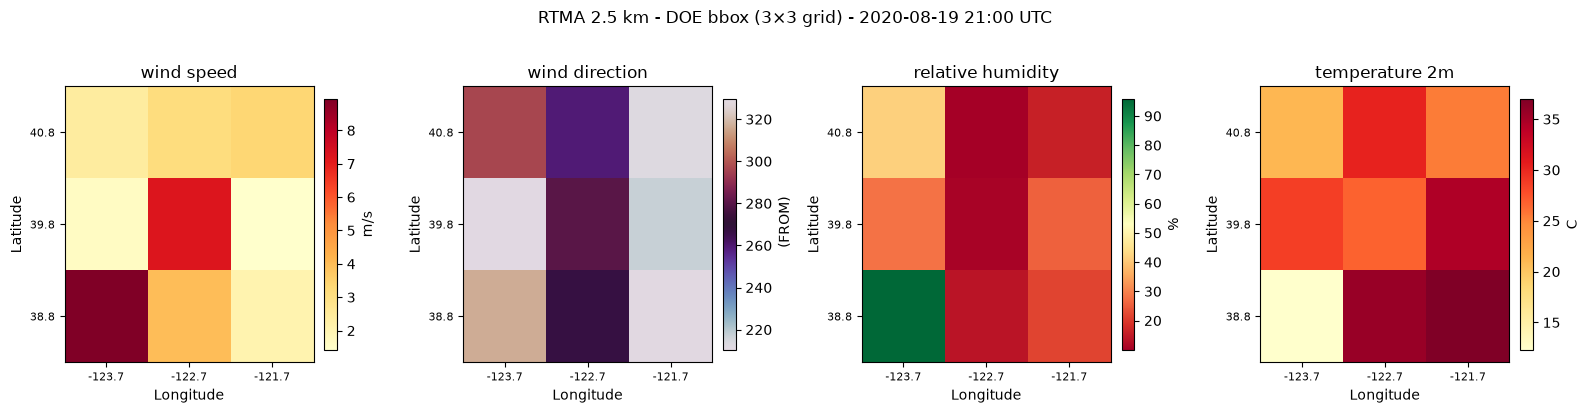


Variance across 9 sample points (temperature in K, wind in m/s, RH in %):


,min,max,range,std
wind_speed,1.430,8.94,7.510,2.608
wind_direction,210.500,329.60,119.100,44.912
relative_humidity,10.068,95.81,85.742,26.841
temperature_2m,285.480,310.13,24.650,7.811
dew_point,267.010,285.12,18.110,7.262
precipitation,NaN,NaN,NaN,NaN


Spatial variation - RTMA 2.5 km - DOE bbox (3×3 grid, ~171 km × ~222 km):

  wind_speed                 range =    7.51  threshold =   1.0  ->  MEANINGFUL
  wind_direction             range =  119.10  threshold =  15.0  ->  MEANINGFUL
  relative_humidity          range =   85.74  threshold =   5.0  ->  MEANINGFUL
  temperature_2m             range =   24.65  threshold =   2.0  ->  MEANINGFUL
  dew_point                  range =   18.11  threshold =   2.0  ->  MEANINGFUL
  precipitation              range = N/A  (not available from RTMA 2.5 km)

Spatial variation is meaningful in: ['wind_speed', 'wind_direction', 'relative_humidity', 'temperature_2m', 'dew_point'].


In [29]:
rtma_df = sample_source(fetch_rtma_point, "RTMA", 2.5)
rtma_stats = plot_spatial_heatmaps(rtma_df, "RTMA 2.5 km")
rtma_meaningful = assess_variation(rtma_stats, "RTMA 2.5 km")

Sampling 9 points (3×3 grid) - HRRR 3.0 km
~171 km × ~222 km  |  valid time: 2020-08-19 21:00 UTC

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 20:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 1/9] (40.77N, -123.67)  wind=2.9 m/s @ 309  RH=50%  T=17.8C
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 20:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 2/9] (40.77N, -122.67)  wind=3.7 m/s @ 252  RH=10%  T=29.1C
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 20:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local
  [ 3/9] (40.77N, -121.67)  wind=4.2 m/s @ 247  RH=11%  T=26.8C
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-19 20:00 UTC F01 ┊ GRIB2 @

,latitude_requested,longitude_requested,grid_latitude,grid_longitude,grid_distance_km,wind_speed,wind_direction,relative_humidity,temperature_2m,dew_point,precipitation
point_idx,,,,,,,,,,,
0,40.765,-123.673,40.769,-123.663,0.960,2.923,309.257,50.1,290.912,280.393,0.0
1,40.765,-122.673,40.762,-122.661,1.119,3.697,251.868,9.7,302.224,266.205,0.0
2,40.765,-121.673,40.773,-121.668,0.939,4.167,246.664,10.6,299.974,265.518,0.0
3,39.765,-123.673,39.754,-123.679,1.353,2.440,291.949,43.7,296.474,283.518,0.0
4,39.765,-122.673,39.781,-122.667,1.767,3.981,286.035,11.0,302.287,267.955,0.0
5,39.765,-121.673,39.765,-121.679,0.488,2.539,234.823,14.9,308.099,277.580,0.0
6,38.765,-123.673,38.772,-123.672,0.772,9.600,334.464,96.4,286.724,286.205,0.0
7,38.765,-122.673,38.773,-122.664,1.151,3.451,310.138,14.5,307.412,276.080,0.0
8,38.765,-121.673,38.765,-121.656,1.481,2.072,36.655,17.8,308.724,280.643,0.0


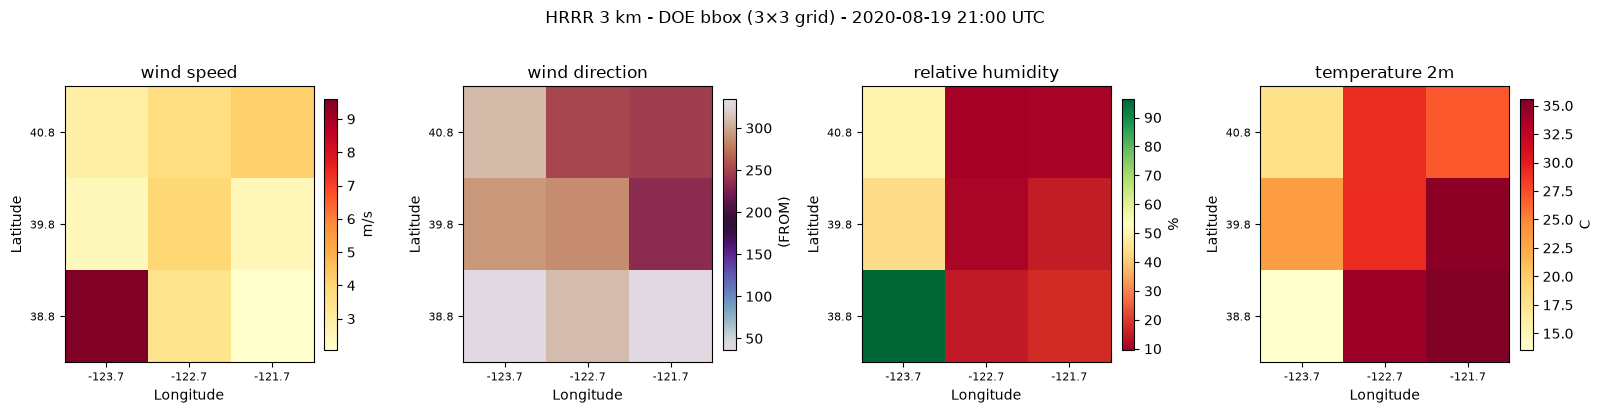


Variance across 9 sample points (temperature in K, wind in m/s, RH in %):


,min,max,range,std
wind_speed,2.072,9.600,7.528,2.266
wind_direction,36.655,334.464,297.809,88.588
relative_humidity,9.700,96.400,86.700,29.084
temperature_2m,286.724,308.724,22.000,7.723
dew_point,265.518,286.205,20.687,7.702
precipitation,0.000,0.000,0.000,0.000


Spatial variation - HRRR 3 km - DOE bbox (3×3 grid, ~171 km × ~222 km):

  wind_speed                 range =    7.53  threshold =   1.0  ->  MEANINGFUL
  wind_direction             range =  297.81  threshold =  15.0  ->  MEANINGFUL
  relative_humidity          range =   86.70  threshold =   5.0  ->  MEANINGFUL
  temperature_2m             range =   22.00  threshold =   2.0  ->  MEANINGFUL
  dew_point                  range =   20.69  threshold =   2.0  ->  MEANINGFUL
  precipitation              range =    0.00  threshold =   0.1  ->  near-zero

Spatial variation is meaningful in: ['wind_speed', 'wind_direction', 'relative_humidity', 'temperature_2m', 'dew_point'].


In [30]:
hrrr_df = sample_source(fetch_hrrr_point, "HRRR", 3.0)
hrrr_stats = plot_spatial_heatmaps(hrrr_df, "HRRR 3 km")
hrrr_meaningful = assess_variation(hrrr_stats, "HRRR 3 km")

## Resolution Sufficiency Assessment

Are the free public sources (2.5–3km) fine enough for fire risk modeling,
or is a paid sub-kilometer source required? Questioning this because the NASA VIIRS satellite data has a spatial resolution of 375m.

### Operational Fire Behavior Model Weather Resolution Benchmarks

| Model | Jurisdiction | Weather input method | Effective weather resolution |
|---|---|---|---|
| FARSITE | US (standard fire spread) | RAWS station streams, one station per fire | ~10–50 km (station spacing) |
| FlamMap | US (fuel/behavior mapping) | Same RAWS station inputs as FARSITE | ~10–50 km |
| NFDRS | US (national fire danger rating) | RAWS point observations | ~10–50 km |
| Phoenix RapidFire | Australia (operational) | BOM ACCESS-C gridded NWP | ~1.5–3 km |
| WRF-SFIRE | Research (coupled fire-atmosphere) | WRF coupled meteorology | ~1–3 km |
| NWS RTMA / NDFD | US (operational fire weather products) | Gridded analysis/forecast | 2.5 km |

finding: US operational models (FARSITE, FlamMap, NFDRS) rely on *station-based* weather - typically a single RAWS station per fire at distances of 10-50 km from the fire origin. The 2.5 km RTMA and 3 km HRRR grids already exceed what any deployed US operational fire behavior model uses for weather inputs. The NWS RTMA at 2.5 km is the de facto standard for gridded US fire weather analysis. This sets the resolution benchmark: <= 3km is more than sufficient.

In [32]:
firms_j1 = pq.read_table(
    "../data/firms_historical/fire_archive_J1V-C2_749170_ca.parquet"
).to_pandas()
firms_snpp = pq.read_table(
    "../data/firms_historical/fire_archive_SV-C2_749171_ca.parquet"
).to_pandas()
firms_all = pd.concat([firms_j1, firms_snpp], ignore_index=True)

lon_min, lat_min, lon_max, lat_max = DOE_BBOX
peak_mask = firms_all["acq_date"].astype(str) == DOE_PEAK_DATE
bbox_mask = (
    (firms_all["longitude"] >= lon_min)
    & (firms_all["longitude"] <= lon_max)
    & (firms_all["latitude"] >= lat_min)
    & (firms_all["latitude"] <= lat_max)
)
type_mask = firms_all["type"] == 0

doe_peak = firms_all[peak_mask & bbox_mask & type_mask].copy()
print(
    f"DOE bbox, {DOE_PEAK_DATE}: {len(doe_peak):,} hotspots (type=0, both satellites)"
)

c_lat_min = doe_peak["latitude"].min()
c_lat_max = doe_peak["latitude"].max()
c_lon_min = doe_peak["longitude"].min()
c_lon_max = doe_peak["longitude"].max()

print(f"Cluster WGS84 extent (hotspot hull):")
print(f"  Lat: {c_lat_min:.4f} -> {c_lat_max:.4f}  (diff {c_lat_max - c_lat_min:.4f})")
print(f"  Lon: {c_lon_min:.4f} -> {c_lon_max:.4f}  (diff{c_lon_max - c_lon_min:.4f})")

# Reproject corner points to UTM Zone 10N (EPSG:32610) for metric distances
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32610", always_xy=True)
x_sw, y_sw = transformer.transform(c_lon_min, c_lat_min)
x_ne, y_ne = transformer.transform(c_lon_max, c_lat_max)

width_km = (x_ne - x_sw) / 1000
height_km = (y_ne - y_sw) / 1000
area_km2 = width_km * height_km

print(f"Cluster bounding box (UTM 32610):")
print(f"Width  (E-W): {width_km:.1f} km")
print(f"Height (N-S): {height_km:.1f} km")
print(f"Bbox area: {area_km2:,.0f} km^2")

HRRR_RES_KM = 3.0
RTMA_RES_KM = 2.5

hrrr_nx = math.ceil(width_km / HRRR_RES_KM)
hrrr_ny = math.ceil(height_km / HRRR_RES_KM)
rtma_nx = math.ceil(width_km / RTMA_RES_KM)
rtma_ny = math.ceil(height_km / RTMA_RES_KM)

print(f"Grid cells spanning the peak-day cluster bbox:")
print(f"HRRR  3.0 km: {hrrr_nx} x {hrrr_ny} = {hrrr_nx * hrrr_ny:,} cells")
print(f"RTMA  2.5 km: {rtma_nx} x {rtma_ny} = {rtma_nx * rtma_ny:,} cells")
print(
    f"-> The DOE fire at peak day spans {hrrr_nx * hrrr_ny} HRRR / {rtma_nx * rtma_ny} RTMA grid cells."
)

DOE bbox, 2020-08-19: 5,293 hotspots (type=0, both satellites)
Cluster WGS84 extent (hotspot hull):
  Lat: 38.7654 -> 40.7368  (diff 1.9714)
  Lon: -123.2028 -> -121.6742  (diff1.5286)
Cluster bounding box (UTM 32610):
Width  (E-W): 129.6 km
Height (N-S): 219.6 km
Bbox area: 28,454 km^2
Grid cells spanning the peak-day cluster bbox:
HRRR  3.0 km: 44 x 74 = 3,256 cells
RTMA  2.5 km: 52 x 88 = 4,576 cells
-> The DOE fire at peak day spans 3256 HRRR / 4576 RTMA grid cells.


In [33]:
# At what cluster size does spatial sampling stop being meaningful?
# A cluster must span > 1 grid cell in at least one direction for any spatial
# variation in weather to be observable across it
# Below that threshold, every sample point snaps to the same grid cell -> identical values

cluster_sizes_km = [0.5, 1.0, 2.0, 3.0, 5.0, 6.0, 10.0, 20.0]

rows = []
for d in cluster_sizes_km:
    hrrr_cells = math.ceil(d / HRRR_RES_KM)
    rtma_cells = math.ceil(d / RTMA_RES_KM)
    rows.append(
        {
            "cluster_diameter_km": d,
            f"HRRR ({HRRR_RES_KM:.0f} km) cells": hrrr_cells,
            f"RTMA ({RTMA_RES_KM:.1f} km) cells": rtma_cells,
            "HRRR spatial variation?": "yes" if hrrr_cells > 1 else "no - single cell",
            "RTMA spatial variation?": "yes" if rtma_cells > 1 else "no - single cell",
        }
    )

size_df = pd.DataFrame(rows)
display(size_df)

hrrr_cutoff = next(
    r["cluster_diameter_km"]
    for r in rows
    if r[f"HRRR ({HRRR_RES_KM:.0f} km) cells"] > 1
)
rtma_cutoff = next(
    r["cluster_diameter_km"]
    for r in rows
    if r[f"RTMA ({RTMA_RES_KM:.1f} km) cells"] > 1
)

print(f"\nCutoff summary:")
print(
    f"  HRRR (3.0 km): first spatial variation when cluster diameter > {HRRR_RES_KM:.0f} km  (threshold: ~{hrrr_cutoff} km)"
)
print(
    f"  RTMA (2.5 km): first spatial variation when cluster diameter > {RTMA_RES_KM:.1f} km  (threshold: ~{rtma_cutoff} km)"
)

,cluster_diameter_km,HRRR (3 km) cells,RTMA (2.5 km) cells,HRRR spatial variation?,RTMA spatial variation?
0,0.5,1,1,no - single cell,no - single cell
1,1.0,1,1,no - single cell,no - single cell
2,2.0,1,1,no - single cell,no - single cell
3,3.0,1,2,no - single cell,yes
4,5.0,2,2,yes,yes
5,6.0,2,3,yes,yes
6,10.0,4,4,yes,yes
7,20.0,7,8,yes,yes



Cutoff summary:
  HRRR (3.0 km): first spatial variation when cluster diameter > 3 km  (threshold: ~5.0 km)
  RTMA (2.5 km): first spatial variation when cluster diameter > 2.5 km  (threshold: ~3.0 km)


Findings:

ST-DBSCAN (ε₁=1km, min_samples=3) early-stage clusters: ~2–3 km diameter.These fall below the HRRR cutoff. All sample points within a 2–3 km cluster return the same grid cell value. Multi-point sampling adds no information.

Implication for pipelining later on:
  - Use centroid fetch for all clusters (constant cost, sufficient for early-stage fires).
  - The 9-point spatial sampling from the Multi-Sampling section is a check and not needed per-cluster.
  - For clusters that have grown > 5 km, a 3×3 grid fetch could capture fire-front gradients in wind/RH, but the added cost (~9× API calls, which took a relatively large amount of time) must be weighed against the any gain in feature signal (future testing during modeling should answer how much of a gain this is).


Overall, the free APIs (RTMA or HRRR) are sufficient from a resolution standpoint. US operational fire behavior models (FARSITE, FlamMap, NFDRS) use RAWS station weather at ~10–50 km spacing which is far coarser than 2.5–3 km gridded products. The NWS RTMA at 2.5 km is the US operational standard for gridded fire weather analysis. HRRR (3 km) and RTMA (2.5 km) both meet or exceed the operational benchmark. Early-stage fire clusters (ST-DBSCAN ε₁=1 km, ~2–3 km wide) fall within a single grid cell at both resolutions, centroid fetching is sufficient in this case. Large fires (e.g., DOE peak day: ~60 km wide, spanning 20+ HRRR cells) do exhibit meaningful spatial variation at 2.5–3 km, captured by the centroid + surrounding context. From this, it seems no sub-kilometer paid API is needed for ML feature engineering at the cluster level.

## Conclusions

In [34]:
print("=" * 72)
print("API COMPARISON SUMMARY")
print("=" * 72)
display(comparison_df)

print("\n" + "=" * 72)
print(f"VARIABLE VALUES AT DOE CENTROID  ({DOE_PEAK_DATE} {DOE_PEAK_HOUR:02d}:00 UTC)")
print("=" * 72)
display(values_df)

print("\n" + "=" * 72)
print("SPATIAL VARIATION ACROSS DOE BBOX  (3×3 sample grid)")
print("=" * 72)
_var_cols = [
    v for v in TARGET_VARIABLES if v in rtma_stats.index and v in hrrr_stats.index
]
spatial_df = pd.DataFrame(
    {
        "RTMA 2.5 km  range": rtma_stats.loc[_var_cols, "range"],
        "RTMA meaningful?": [
            "yes" if v in rtma_meaningful else "no" for v in _var_cols
        ],
        "HRRR 3 km   range": hrrr_stats.loc[_var_cols, "range"],
        "HRRR meaningful?": [
            "yes" if v in hrrr_meaningful else "no" for v in _var_cols
        ],
    }
)
display(spatial_df.round(2))

API COMPARISON SUMMARY


,resolution_km,temporal_res_h,coverage_start,n_vars,vars_missing,training,inference,ingestion
source,,,,,,,,
HRRR,3.0,1,2014-08-01,6,-,yes,yes,herbie + GRIB2/cfgrib + point extraction
RTMA,2.5,1,2017-05-02,5,precipitation,yes,yes,herbie + GRIB2/cfgrib + point extraction
NWS,2.5,1,N/A,5,precipitation,no,yes,"REST API, no auth (User-Agent header only)"
Open-Meteo,9.0,1,2017-01-01,6,-,yes,yes,"REST API, no auth"



VARIABLE VALUES AT DOE CENTROID  (2020-08-19 21:00 UTC)


,HRRR,RTMA,NWS,Open-Meteo
wind_speed,3.98,7.23,NaN,5.59
wind_direction,286.04,280.20,NaN,260.00
relative_humidity,11.00,11.07,NaN,13.00
temperature_2m,302.29,299.84,NaN,299.35
dew_point,267.96,267.01,NaN,268.75
precipitation,0.00,NaN,NaN,0.00
temperature_2m (C),29.14,26.69,NaN,26.20
dew_point (C),-5.19,-6.14,NaN,-4.40



SPATIAL VARIATION ACROSS DOE BBOX  (3×3 sample grid)


,RTMA 2.5 km range,RTMA meaningful?,HRRR 3 km range,HRRR meaningful?
wind_speed,7.51,yes,7.53,yes
wind_direction,119.10,yes,297.81,yes
relative_humidity,85.74,yes,86.70,yes
temperature_2m,24.65,yes,22.00,yes
dew_point,18.11,yes,20.69,yes
precipitation,NaN,no,0.00,no



Selected source for training and inference: HRRR

confirmed variables:
  - wind_speed
  - wind_direction
  - relative_humidity
  - temperature_2m
  - dew_point
  - precipitation

^ good starting point for features for modeling, can look deeper at all available features when doing feature engineering


sampling strategy: centroid

need paid api? No, phew

open questions:
  - Wind direction is circular - encode as sin/cos pair (sin(θ), cos(θ))
    rather than raw degrees for ML inputs.
  - Precipitation is near-zero during active fire weather; test whether the
    variable adds signal before keeping the two-fetch HRRR ingestion (fxx=0 +
    fxx=1 from previous cycle). It is mostly likely for there to no be precipiation during an active fire, especially during a large one such as the DOE fire used in this EDA, however, it should still be accounted for as it would likely have a meaningful impact when it does occur. further EDA could be done on this and find fires in which there was precipitation.
  - RTMA (2.5 km analysis product) may give more accurate historical weather
    estimates than HRRR (3 km forecast-model analysis). If precipitation is
    dropped as a feature, RTMA becomes the preferred training source, but as of now HRRR seems to be the richer source.

pipeline implications:
  - HRRR instantaneous fields: fxx=0. HRRR 1-hour precipitation: init at
    valid_time − 1h with fxx=1.
      - aka the precipiation is recorded in hour intervals, so to get the precipation value at time X, we need to look at time X-1 in order to get this.
  - One centroid fetch per cluster per valid hour; no spatial grid sampling
    needed for early fires. During modeling, test to see if grid sampling (or random/different sampling methods) are useful for larger fires.
  - Temperatures are in Kelvin from both HRRR and RTMA, convert to Celsius/Fahrenheit
    only for display, keep Kelvin internally.
  - Wind speed/direction derived from 10m UGRD/VGRD in HRRR; native WIND/WDIR
    fields in RTMA.

### Overall Findings

Of the four sources looked at, HRRR is is the choice for both training and inference. It is the only free source that gives all six fire-relevvant variables (wind speed, wind direction, relative humidity, 2m temperature, dew point, and 1-hour precipitation) at a resolution (3 km) that meets or exceeds the operational fire weather benchmark (NWS RTMA at 2.5 km).

RTMA is a good alternative for the five non-precipitation variables. As a dedicated analysis product rather than a forecast model output, it gives the best estimate of surface conditions and is marginally finer at 2.5 km. Its weakness is the missing precipitation field, which would require either a second fetch from HRRR or dropping precipitation as a feature. If model evaluation shows precipitation adds little signal during fire weather (it seems to be near-zero on most fire days), RTMA becomes the better choice.

NWS api.weather.gov is viable only at inference time. It carries no historical archive, so it cannot contribute training data. Its variable encoding (wind speed as a string range in mph, wind direction as a cardinal abbreviation) also adds a parsing layer not present in the GRIB2 sources. It is worth keeping as a lightweight fallback in the live inference path if HRRR is temporarily unavailable, or if it is more lightweight to use in the live serice. But would rather choose a source that can be used for both historical training and live inference.

Open-Meteo is the simplest integration being a plain REST call with no GRIB2 or herbie dependency and it covers all six variables. Its resolution of 9km is three times coarser than HRRR, though for early-stage fire clusters (ST-DBSCAN epsilon=1 km, typically 2–3 km wide) this is inconsequential: all four sources return a single grid-cell value at that scale. The resolution difference only matters for fires that have grown to span multiple grid cells (roughly > 5 km), where HRRR and RTMA capture fire-front weather gradients that Open-Meteo smooths over. Open-Meteo is a reasonable prototype or fallback source but not the final choice since this project hinges on predicting and giving scores for fires as early as possible.

On spatial sampling: the 3x3 multi-point grid tested in the Multi-Sampling section is most likely not needed, but further testing during modeling may change that. Early-stage clusters fit within a single 3 km or 2.5 km grid cell; all nine sample points return the same value and the added ingestion cost (roughly 9× the API call volume) provides nothing. A single centroid fetch per cluster per hour is the right default. For larger fires spanning tens of kilometers, meaningful weather gradients do exist at HRRR/RTMA resolution, but the cluster centroid already sits within that gradient, so per-cluster multi-point sampling can be revisited during feature engineering if spatial weather features improve model performance.